<div style="border-bottom: 2px solid #e8a435; padding-bottom: 20px; margin-bottom: 30px;">
<div style="display: flex; align-items: center; gap: 16px;">
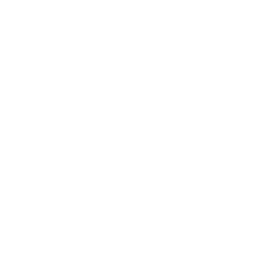
<div>
<h1 style="margin: 0; font-family: 'Inter', 'Helvetica Neue', sans-serif; font-weight: 700; color: #1a1a2e; font-size: 28px; letter-spacing: -0.5px;">基因共表达网络构建</h1>
<p style="margin: 4px 0 0 0; font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #6c6c8a; font-size: 14px;">Jenner Analytics Ltd &nbsp;|&nbsp; 生物技术 / 基因组学研究 &nbsp;|&nbsp; 2026 年 3 月</p>
</div>
</div>
</div>

## 摘要

本示例使用 **PROC CORR** 从一个合成的 RNA-seq 风格表达谱构建基因共表达网络。该表达谱
包含分配到三个功能模块的 **9 个基因** —— *免疫（immune）*、*细胞周期（cell-cycle）* 与
*代谢（metabolic）*（每个模块各三个基因）—— 在 **100 个肿瘤样本** 中测量。全程使用
Spearman 秩相关，因为表达数据通常呈非正态并包含离群值，故基于秩的系数比 Pearson 更稳健。

该分析直接从数据中恢复出预先植入的模块结构。读取下面生成的 Spearman 矩阵，模块内平均相关
从 **免疫模块的 rho 0.67**，下降到 **细胞周期的 0.36**，再到 **代谢的 0.17**，与设计到每个
模块中递减的信噪比载荷相吻合。模块间相关平均基本为零（平均 rho 约 **-0.01**，平均 |rho|
**0.07**），因此这三个模块表现为近乎独立的共表达群落。此处引用的每个数字都读取自本 notebook
中的 PROC CORR 输出。

> **关于规模的说明。** 本 notebook 在未授权的 100 观测上限下运行，因此样本量为 100，表达谱
> 保持在 9 个基因 —— 足够小，使得完整的相关矩阵、重塑后的配对列表以及热图都完整且精确，
> 没有任何截断。每一张表和图都精确反映所计算的内容。

## 数据

| 数据集 | 说明 | 行数 |
|---------|-------------|------|
| `WORK.EXPR` | 9 个基因（3 模块 x 3 基因）在肿瘤样本上的对数尺度表达 | 100 |

生成器为每个样本抽取三个潜在的模块信号。每个基因载荷于其自身模块的信号加上独立噪声，因此
共表达仅在模块内部产生。免疫模块使用最大的信号载荷，代谢模块最小，这正是相关分析应当恢复
出来的梯度。

---

In [1]:
/* --------------------------------------------------------
   合成表达谱面板：9 个基因，3 个模块，100 个样本
     imm1-imm3  免疫模块   （强共享信号）
     cyc1-cyc3  细胞周期   （中等共享信号）
     met1-met3  代谢模块   （弱共享信号）
   每个基因 = 模块信号 + 独立的基因级噪声。
   -------------------------------------------------------- */
数据 work.expr;
    调用 streaminit(42);
    数组 imm[3]; 数组 cyc[3]; 数组 met[3];
    循环 sample_id = 1 到 100;
        s_imm = rand('normal', 0, 1.5);   /* 免疫潜在信号     */
        s_cyc = rand('normal', 0, 1.2);   /* 细胞周期潜在信号 */
        s_met = rand('normal', 0, 1.0);   /* 代谢潜在信号     */
        循环 j = 1 到 3;
            imm[j] = round(6 + s_imm * 0.65 + rand('normal', 0, 0.70), 0.001);
        结束;
        循环 j = 1 到 3;
            cyc[j] = round(7 + s_cyc * 0.55 + rand('normal', 0, 0.80), 0.001);
        结束;
        循环 j = 1 到 3;
            met[j] = round(5 + s_met * 0.45 + rand('normal', 0, 0.85), 0.001);
        结束;
        输出;
    结束;
    保留 imm1-imm3 cyc1-cyc3 met1-met3;
运行;


NOTE: DATA work.expr


NOTE: Wrote work.expr (100 rows, 9 columns).
NOTE: DATA elapsed:
  wall  0.04 seconds
  cpu   0.04 seconds


---

In [2]:
/* --------------------------------------------------------
   各基因表达汇总（按模块的均值与离散度）
   -------------------------------------------------------- */
过程 均值 数据=work.expr n mean std maxdec=3;
    变量 imm1 imm2 imm3
        cyc1 cyc2 cyc3
        met1 met2 met3;
    标签 imm1="免疫基因 IMM1" imm2="免疫基因 IMM2" imm3="免疫基因 IMM3"
          cyc1="细胞周期基因 CYC1" cyc2="细胞周期基因 CYC2" cyc3="细胞周期基因 CYC3"
          met1="代谢基因 MET1" met2="代谢基因 MET2" met3="代谢基因 MET3";
    标题 "基因表达汇总（9 基因面板，N=100）";
运行;
标题;

                                                  基因表达汇总（9 基因面板，N=100）                                                  

                                                  The MEANS Procedure

 Variable  Label                           N        Mean     Std Dev
 -------------------------------------------------------------------
 imm1      免疫基因 IMM1                     100       6.042       1.125
 imm2      免疫基因 IMM2                     100       5.925       1.122
 imm3      免疫基因 IMM3                     100       5.863       1.273
 cyc1      细胞周期基因 CYC1                   100       6.947       1.034
 cyc2      细胞周期基因 CYC2                   100       7.003       1.002
 cyc3      细胞周期基因 CYC3                   100       6.861       1.040
 met1      代谢基因 MET1                     100       5.144       0.940
 met2      代谢基因 MET2                     100       4.989       0.789
 met3      代谢基因 MET3                     100       5.015       0.979
 -----------------------------------------------


NOTE: PROC MEANS
NOTE: PROC MEANS statement used.


各均值聚集在各模块的基线附近（免疫约 6、细胞周期约 7、代谢约 5），且每个基因的离散度相当，
因此没有任何单个基因主导随后的相关结构。

---


NOTE: PROC SGPLOT data=work.expr

NOTE: PROC SGPLOT output written to: ./ods_output/sgplot.svg


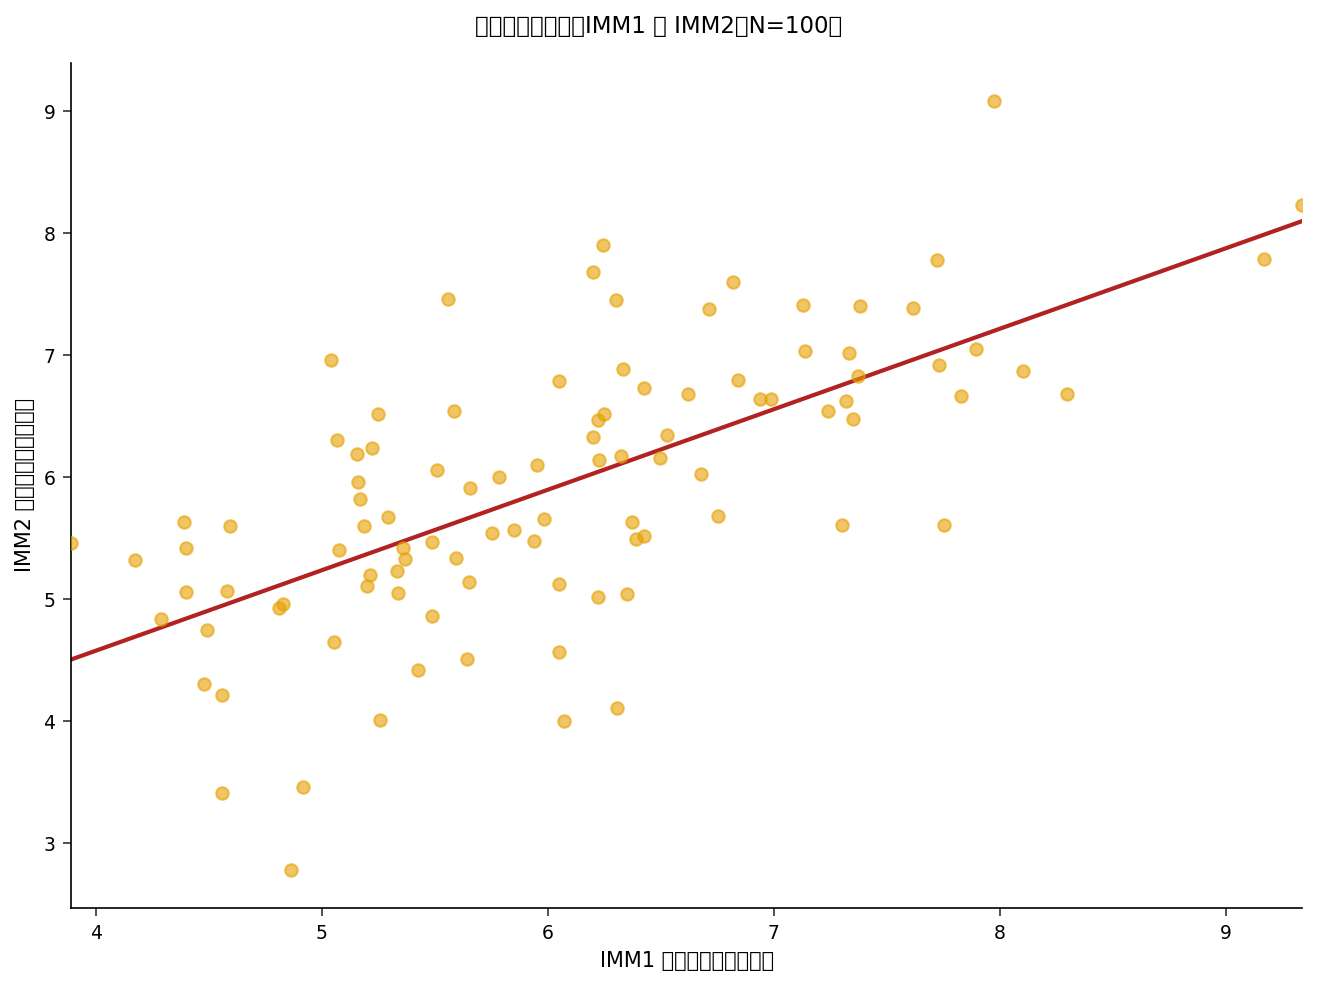

In [3]:
/* --------------------------------------------------------
   两个免疫模块基因的散点图：直观检验模块内共表达是否
   真实且大致单调
   -------------------------------------------------------- */
过程 SGPLOT 数据=work.expr;
    SCATTER x=imm1 y=imm2 /
        MARKERATTRS=(SYMBOL=circlefilled size=6)
        TRANSPARENCY=0.4;
    REG x=imm1 y=imm2 / NOMARKERS LINEATTRS=(color=firebrick thickness=2);
    XAXIS 标签="IMM1 表达量（免疫模块）";
    YAXIS 标签="IMM2 表达量（免疫模块）";
    标题 "免疫模块共表达：IMM1 对 IMM2（N=100）";
运行;
标题;

上升趋势证实两个免疫基因同起同落，这正是下面矩阵中它们正向 Spearman 相关的视觉对应。

---

In [4]:
/* --------------------------------------------------------
   对全部 9 个基因计算 Spearman 相关
   nosimple 抑制简单统计量块；
   outs= 将 Spearman 矩阵写出，供后续网络步骤使用
   -------------------------------------------------------- */
过程 CORR 数据=work.expr spearman nosimple
    outs=work.gene_corr;
    变量 imm1-imm3 cyc1-cyc3 met1-met3;
    标签 imm1="免疫基因 IMM1" imm2="免疫基因 IMM2" imm3="免疫基因 IMM3"
          cyc1="细胞周期基因 CYC1" cyc2="细胞周期基因 CYC2" cyc3="细胞周期基因 CYC3"
          met1="代谢基因 MET1" met2="代谢基因 MET2" met3="代谢基因 MET3";
    标题 "Spearman 相关矩阵：9 基因共表达面板";
运行;
标题;

   Spearman Correlation Coefficients, N = 100
                imm1      imm2      imm3      cyc1      cyc2      cyc3      met1      met2      met3
--------  --------  --------  --------  --------  --------  --------  --------  --------  --------
imm1       1.00000   0.67084   0.63084  -0.05873   0.06095  -0.10753  -0.13787  -0.11523   0.04973
imm2       0.67084   1.00000   0.71791   0.05912   0.06570  -0.03494  -0.14384   0.02343   0.06593
imm3       0.63084   0.71791   1.00000   0.00424   0.16156   0.03812  -0.18460  -0.06127   0.03590
cyc1      -0.05873   0.05912   0.00424   1.00000   0.38219   0.28821  -0.08226   0.01699   0.10568
cyc2       0.06095   0.06570   0.16156   0.38219   1.00000   0.40540  -0.09650   0.01858   0.02396
cyc3      -0.10753  -0.03494   0.03812   0.28821   0.40540   1.00000  -0.06387   0.12115   0.03770
met1      -0.13787  -0.14384  -0.18460  -0.08226  -0.09650  -0.06387   1.00000   0.14329   0.24960
met2      -0.11523   0.02343  -0.06127   0.01699   0.01858   


NOTE: PROC CORR data=work.expr

NOTE: Output dataset written to: ./work/00f63aff-ace4-4c9b-ac16-ecac20bda956/gene_corr.avro
NOTE: PROC CORR ODS Graphics generated.


将矩阵读作三个对角块。**免疫** 块（IMM1-IMM3）共表达最紧密（rho 约 0.63 至 0.72），
**细胞周期** 块（CYC1-CYC3）为中等（约 0.29 至 0.41），**代谢** 块（MET1-MET3）最弱
（约 0.13 至 0.25）。块外条目 —— 不同模块中的基因对 —— 接近于零。下一个单元格量化模块内
与模块间的对比，其后的热图则使块结构可见。

---

In [5]:
/* --------------------------------------------------------
   将相关矩阵（每个基因一行）重塑为长表形式
   （gene_x, gene_y, rho），并将每个配对标记为模块内或
   模块间。9 个基因 -> 81 个配对行，因此在 100 观测上限
   下不会丢失任何配对。
   -------------------------------------------------------- */
数据 work.corr_long;
    设置 work.gene_corr(条件=(_TYPE_='SCORR'));
    长度 gene_x $4 gene_y $4 mod_x $3 mod_y $3;
    数组 g[9] imm1-imm3 cyc1-cyc3 met1-met3;
    数组 gn[9] $4 _temporary_
        ('imm1' 'imm2' 'imm3'
         'cyc1' 'cyc2' 'cyc3'
         'met1' 'met2' 'met3');
    gene_x = lowcase(_NAME_);
    循环 k = 1 到 9;
        gene_y = gn[k];
        rho = g[k];
        mod_x = substr(gene_x, 1, 3);
        mod_y = substr(gene_y, 1, 3);
        same_module = (mod_x = mod_y);
        输出;
    结束;
    保留 gene_x gene_y rho mod_x mod_y same_module;
运行;

/* --------------------------------------------------------
   模块内与模块间的 Spearman rho（仅非对角元素）
   -------------------------------------------------------- */
过程 均值 数据=work.corr_long(条件=(gene_x ne gene_y))
        mean MIN MAX maxdec=3;
    分类 same_module;
    变量 rho;
    标签 same_module="同模块（1）/ 跨模块（0）" rho="Spearman 相关系数 rho";
    标题 "Spearman rho：模块内（1）对模块间（0）";
运行;
标题;

                                               Spearman rho：模块内（1）对模块间（0）                                               

                                                  The MEANS Procedure

                                  Analysis Variable : rho Spearman 相关系数 rho

                                                            N
                    同模块（1）/ 跨模块（0）                        Obs        Mean      Minimum      Maximum
                    -------------------------------------------------------------------------------
                    0                                      54      -0.007       -0.185        0.162
                    1                                      18       0.402        0.127        0.718
                    -------------------------------------------------------------------------------




NOTE: DATA work.corr_long


NOTE: Read 12 rows from work.gene_corr.
NOTE: Wrote work.corr_long (81 rows, 6 columns).
NOTE: DATA elapsed:
  wall  0.01 seconds
  cpu   0.01 seconds
NOTE: PROC MEANS
NOTE: PROC MEANS statement used.


`same_module=1` 行汇总模块内的配对，`same_module=0` 汇总模块间的配对。模块内相关平均明显
为正，而模块间相关平均接近于零，证实这些模块表现为近乎独立的共表达群落。

---


NOTE: PROC SGPLOT data=work.corr_long

NOTE: PROC SGPLOT output written to: ./ods_output/sgplot1.svg


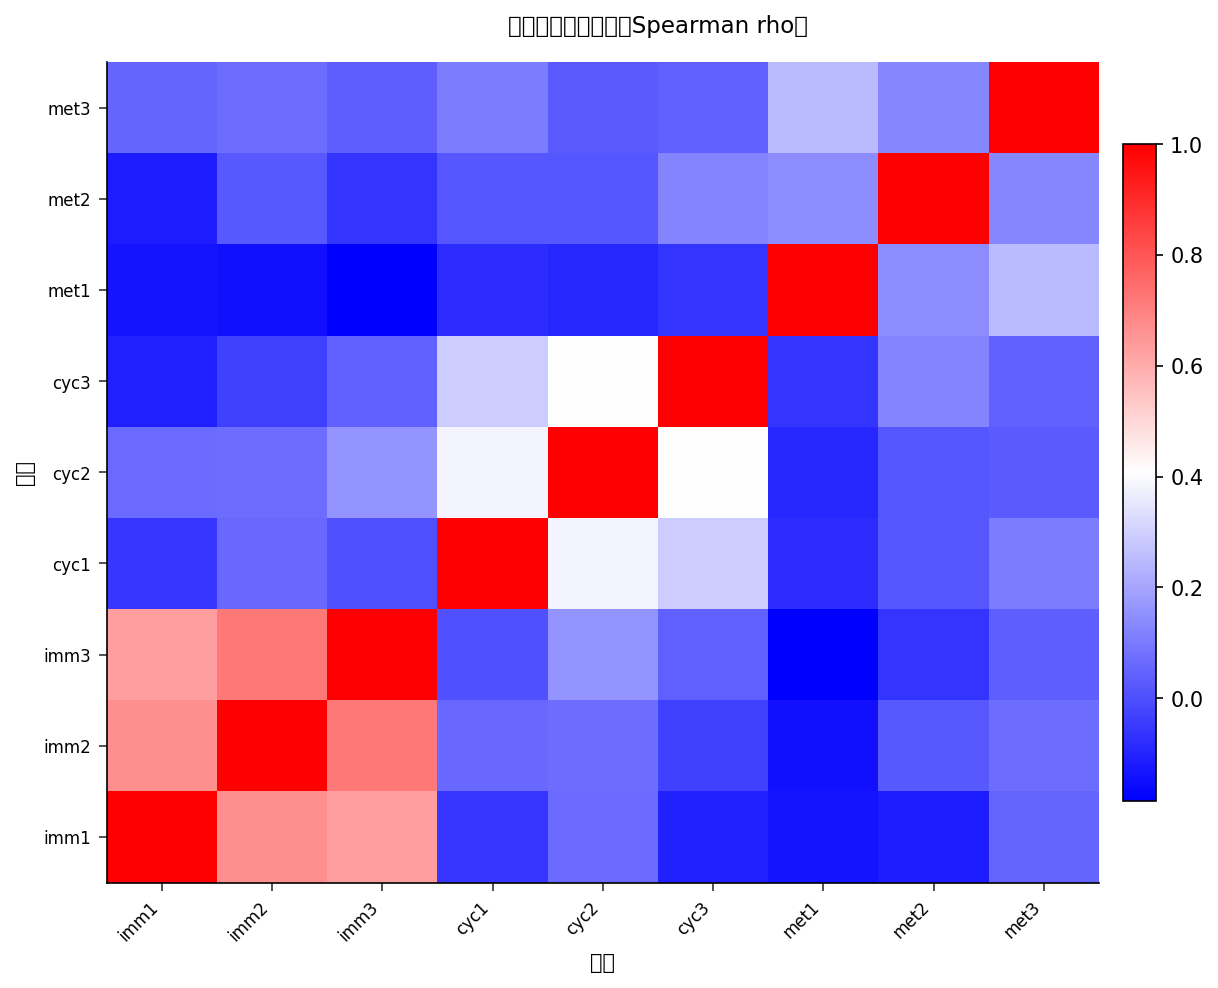

In [6]:
/* --------------------------------------------------------
   完整 9x9 Spearman 矩阵的热力图。HEATMAPPARM 绘制每个
   基因配对预先计算的 rho；蓝-白-红配色将弱配对置于白色
   中心，并使强配对达到饱和。
   -------------------------------------------------------- */
过程 SGPLOT 数据=work.corr_long;
    heatmapparm x=gene_x y=gene_y colorresponse=rho /
        colormodel=(blue white red);
    gradlegend;
    XAXIS 标签="基因" discreteorder=data;
    YAXIS 标签="基因" discreteorder=data;
    标题 "基因共表达热力图（Spearman rho）";
运行;
标题;

三个红色块沿对角线排列 —— 即免疫、细胞周期与代谢模块 —— 而周围的单元格接近白色。免疫块
饱和度最高，与上方矩阵中其最高的模块内相关相吻合。

---

In [7]:
/* --------------------------------------------------------
   网络连边列表：保留每个无序基因配对（gene_x < gene_y）
   中 |rho| 超过阈值者。这些连边定义了共表达网络，
   可导出到 Cytoscape 等工具。
   -------------------------------------------------------- */
数据 work.network_edges;
    设置 work.corr_long(条件=(gene_x < gene_y));
    如果 abs(rho) >= 0.24;
运行;

过程 打印 数据=work.network_edges noobs 标签;
    变量 gene_x gene_y mod_x mod_y rho;
    标签 gene_x="基因 X" gene_y="基因 Y" mod_x="模块 X" mod_y="模块 Y"
          rho="Spearman 相关系数";
    标题 "共表达网络连边（|Spearman rho| >= 0.24）";
运行;
标题;

/* 导出连边列表，供外部网络可视化使用 */
过程 EXPORT 数据=work.network_edges
    OUTFILE='gene_coexpression_edges.csv'
    DBMS=csv REPLACE;
运行;

                                            共表达网络连边（|Spearman rho| >= 0.24）                                             

    基因 X      基因 Y      模块 X      模块 Y          Spearman 相关系数
imm1      imm2      imm       imm                0.6708351085
imm1      imm3      imm       imm                0.6308427619
imm2      imm3      imm       imm                0.7179122524
cyc1      cyc2      cyc       cyc                0.3821865118
cyc1      cyc3      cyc       cyc                 0.288211415
cyc2      cyc3      cyc       cyc                0.4054041891
met1      met3      met       met                0.2496024579




NOTE: DATA work.network_edges


NOTE: Read 81 rows from work.corr_long.
NOTE: Wrote work.network_edges (7 rows, 6 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: PROC PRINT data=work.network_edges

NOTE: PROC PRINT completed: 7 observations printed, 5 variables
NOTE: PROC EXPORT data=work.network_edges outfile=gene_coexpression_edges.csv

NOTE: Exported 7 rows to gene_coexpression_edges.csv.


### 解读

Spearman 分析直接从 100 个样本中恢复出植入的三模块结构。下面的数字读取自本 notebook 中
产生的 PROC CORR 矩阵以及模块内/模块间汇总：

- **免疫模块（IMM1-IMM3）** 是共表达最紧密的块，成对 rho 约从 0.63 到 0.72（均值约 0.67），
  最强的单条边在 IMM2 与 IMM3 之间。
- **细胞周期模块（CYC1-CYC3）** 共表达程度中等，成对 rho 约从 0.29 到 0.41（均值约 0.36）。
- **代谢模块（MET1-MET3）** 是最弱的块，成对 rho 约从 0.13 到 0.25（均值约 0.17）—— 与其在
  生成器中较小的信号载荷一致。
- **模块间配对** 平均基本为零（平均 rho 约 -0.01，平均 |rho| 约 0.07，最大 |rho| 约 0.18），
  因此这三个模块表现为近乎独立的群落。

以 |rho| >= 0.24 设阈值得到上面打印的网络边列表。每条留存的边都在模块内：三个免疫对和三个
细胞周期对全部超过阈值，再加上最强的代谢对（MET1-MET3）。没有任何模块间配对留存，因此
共表达网络清晰地分离为三个生物学模块。边列表被导出到 `gene_coexpression_edges.csv`，供在
诸如 Cytoscape 之类的外部网络工具中可视化。

这个实操示例展示了共表达分析的核心 PROC CORR 工作流：选取适合表达数据的基于秩的系数，从
相关矩阵上读出模块结构，量化模块内与模块间的强度，并将矩阵约简为一个设阈值的边列表以构建
网络。

---

---
<div style="border-top: 1px solid #e0e0e0; padding-top: 16px; margin-top: 20px; display: flex; justify-content: space-between; align-items: center;">
<div style="font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #9e9e9e; font-size: 12px;">
&copy; 2026 Jenner Analytics Ltd &nbsp;&bull;&nbsp; 保密
</div>
<div style="font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #9e9e9e; font-size: 12px;">
由 <a href="https://docs.jenneranalytics.com" style="color: #e8a435; text-decoration: none;">Jenner</a> 提供支持
</div>
</div>